# Week 3 Assignment: Statistical Models (ETS & ARIMA)
**DSE6230: Forecasting Methods and Applications**

In this assignment, you will master classical statistical forecasting frameworks. You will move beyond visual inspection to use formal tests for stationarity and implement ETS and ARIMA models using `statsmodels` and `statsforecast`.

1. **Stationarity Testing**: Using the Augmented Dickey-Fuller (ADF) test.
2. **ETS Models**: Handling Error, Trend, and Seasonality.
3. **SARIMA Models**: Autoregressive Integrated Moving Average with Seasonality.
4. **Model Selection**: Using AICc to choose the best model.

In [1]:
!pip install pandas numpy matplotlib statsmodels statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 1.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsforecast import StatsForecast
from statsmodels.datasets import co2

## Part 1: Self-Guided Exercises (Auto-Graded)

### Setup

In [6]:
# Load CO2 data for exercises
data = co2.load_pandas().data
data = data.resample('ME').mean().ffill()  # Monthly CO2 levels
data.columns = ['co2']

### Exercise 1.1: Testing for Stationarity
**Instruction**: Use the `adfuller` function from `statsmodels` to test if the CO2 data is stationary. Store the p-value in a variable named `p_val`.

In [7]:
# Your Code Here
result = adfuller(data['co2'])
p_val = result[1]
print(f"ADF P-value: {p_val:.4f}")

ADF P-value: 0.9989


/tmp/ipykernel_880/1505553159.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(data['co2'])


In [8]:
#| Check your work
try:
    assert p_val > 0.05, "The CO2 data is non-stationary; p-value should be high."
    print("Exercise 1.1 Passed!")
except AssertionError as e:
    print(f"Exercise 1.1 Failed: {e}")

Exercise 1.1 Passed!


### Exercise 1.2: Exponential Smoothing (ETS)
**Instruction**: Fit an ETS model with **additive trend** and **additive seasonality** (period=12) to the CO2 data. Store the fitted model object in `ets_model`.

In [10]:
# Your Code Here
et_model = ExponentialSmoothing(
    data['co2'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

ets_model = ExponentialSmoothing(
    data['co2'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

print(ets_model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                      co2   No. Observations:                  526
Model:             ExponentialSmoothing   SSE                             56.420
Optimized:                         True   AIC                          -1142.279
Trend:                         Additive   BIC                          -1074.034
Seasonal:                      Additive   AICC                         -1140.930
Seasonal Periods:                    12   Date:                 Wed, 16 Sep 2026
Box-Cox:                          False   Time:                         00:03:29
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.5575636                alpha                 True
smoothing_trend          

In [11]:
#| Check your work
try:
    assert ets_model.model.trend == 'add', "Trend should be additive"
    assert ets_model.model.seasonal == 'add', "Seasonality should be additive"
    print("Exercise 1.2 Passed!")
except AssertionError as e:
    print(f"Exercise 1.2 Failed: {e}")

Exercise 1.2 Passed!


### Exercise 1.3: SARIMA Modeling
**Instruction**: Create a SARIMA model with order $(1, 1, 1)$ and seasonal order $(1, 1, 1, 12)$. Fit the model and store the result in `sarima_result`.

In [12]:
# Your Code Here
model = SARIMAX(data['co2'], order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_result = model.fit(disp=False)

In [13]:
#| Check your work
try:
    assert sarima_result.specification['order'] == (1, 1, 1), "ARIMA order is incorrect"
    assert sarima_result.specification['seasonal_order'] == (1, 1, 1, 12), "Seasonal order is incorrect"
    print("Exercise 1.3 Passed!")
except AssertionError as e:
    print(f"Exercise 1.3 Failed: {e}")

Exercise 1.3 Passed!


## Part 2: Textbook Exercises

Complete the following exercises from *fpppy* Chapters 8 and 9.

### Question 8.1
> Apply Holt's linear method to the `co2` data. Experiment with different values of $\alpha$ and $\beta$. What happens to the forecasts as these parameters change?

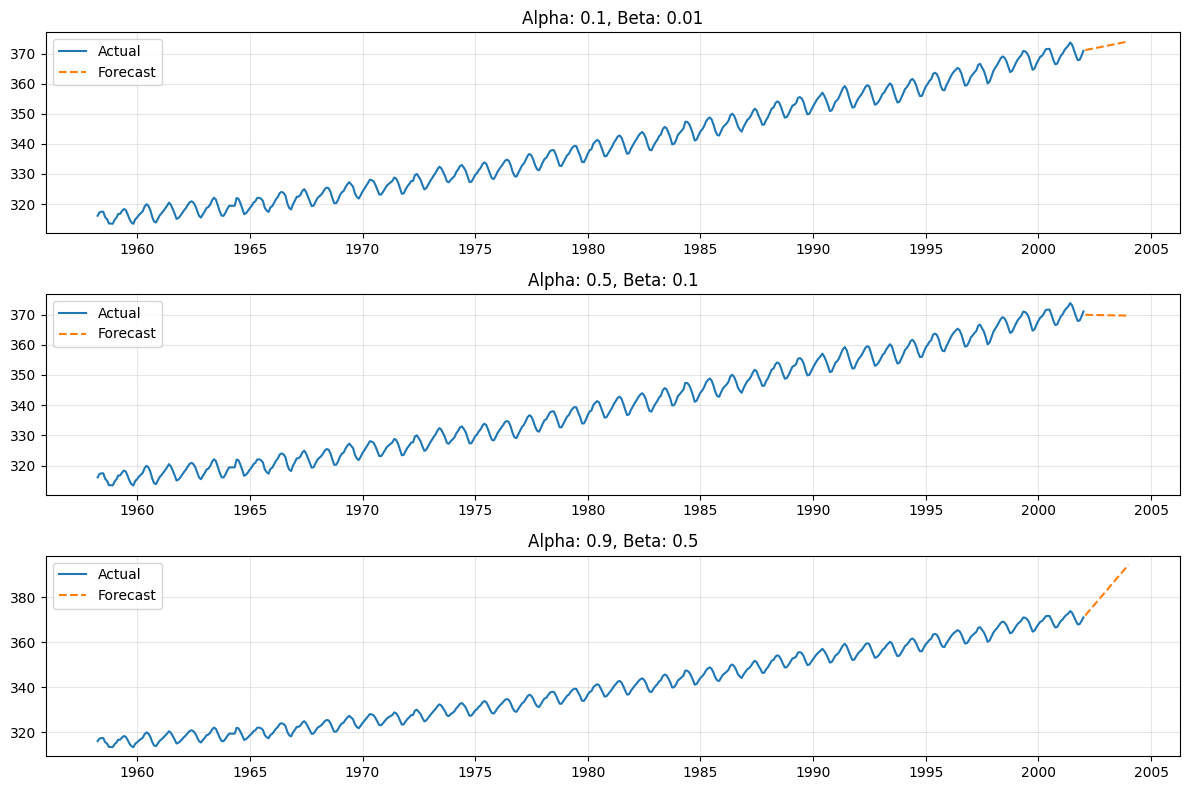

Model Comparison:
α=0.1, β=0.01 → AIC: 806.62, BIC: 823.68
α=0.5, β=0.1 → AIC: 694.40, BIC: 711.47
α=0.9, β=0.5 → AIC: 238.87, BIC: 255.93


In [14]:
# Your code here
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

#Fit Holt's linear method with different 𝛼  and 𝛽 combinations
params = [
    {'alpha': 0.1, 'beta': 0.01},
    {'alpha': 0.5, 'beta': 0.1},
    {'alpha': 0.9, 'beta': 0.5},
]

fig, axes = plt.subplots(nrows=len(params), ncols=1, figsize=(12, 8))


for idx, param in enumerate(params):
     # Fit model
    holts_model = ExponentialSmoothing(
        data['co2'],
        trend='add',
        seasonal=None
    ).fit(smoothing_level=param['alpha'], smoothing_trend=param['beta'])

    # Forcast 24 months ahead
    forecast = holts_model.forecast(steps=24)

    # Plot
    ax = axes[idx]
    ax.plot(data.index, data['co2'], label='Actual', linewidth=1.5)
    ax.plot(forecast.index, forecast, label='Forecast', linestyle='--', linewidth=1.5)
    ax.set_title(f"Alpha: {param['alpha']}, Beta: {param['beta']}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print AIC/BIC for each model
print("Model Comparison:")
for param in params:
    model = ExponentialSmoothing(
        data['co2'],
        trend='add',
        seasonal=None
    ).fit(smoothing_level=param['alpha'], smoothing_trend=param['beta'])
    print(f"α={param['alpha']}, β={param['beta']} → AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")


### Question 9.2
> Why is it important to difference the data before fitting an ARMA model? Generate a non-stationary random walk and show its ACF plot before and after differencing.

Stationarity Tests:
--------------------------------------------------
Random Walk p-value: 0.534189 (non-stationary: p > 0.05)
Differenced p-value: 0.000000 (stationary: p < 0.05)


/tmp/ipykernel_880/1836368355.py:19: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  rw_adf = adfuller(random_walk)
/tmp/ipykernel_880/1836368355.py:22: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  diff_adf = adfuller(differenced)


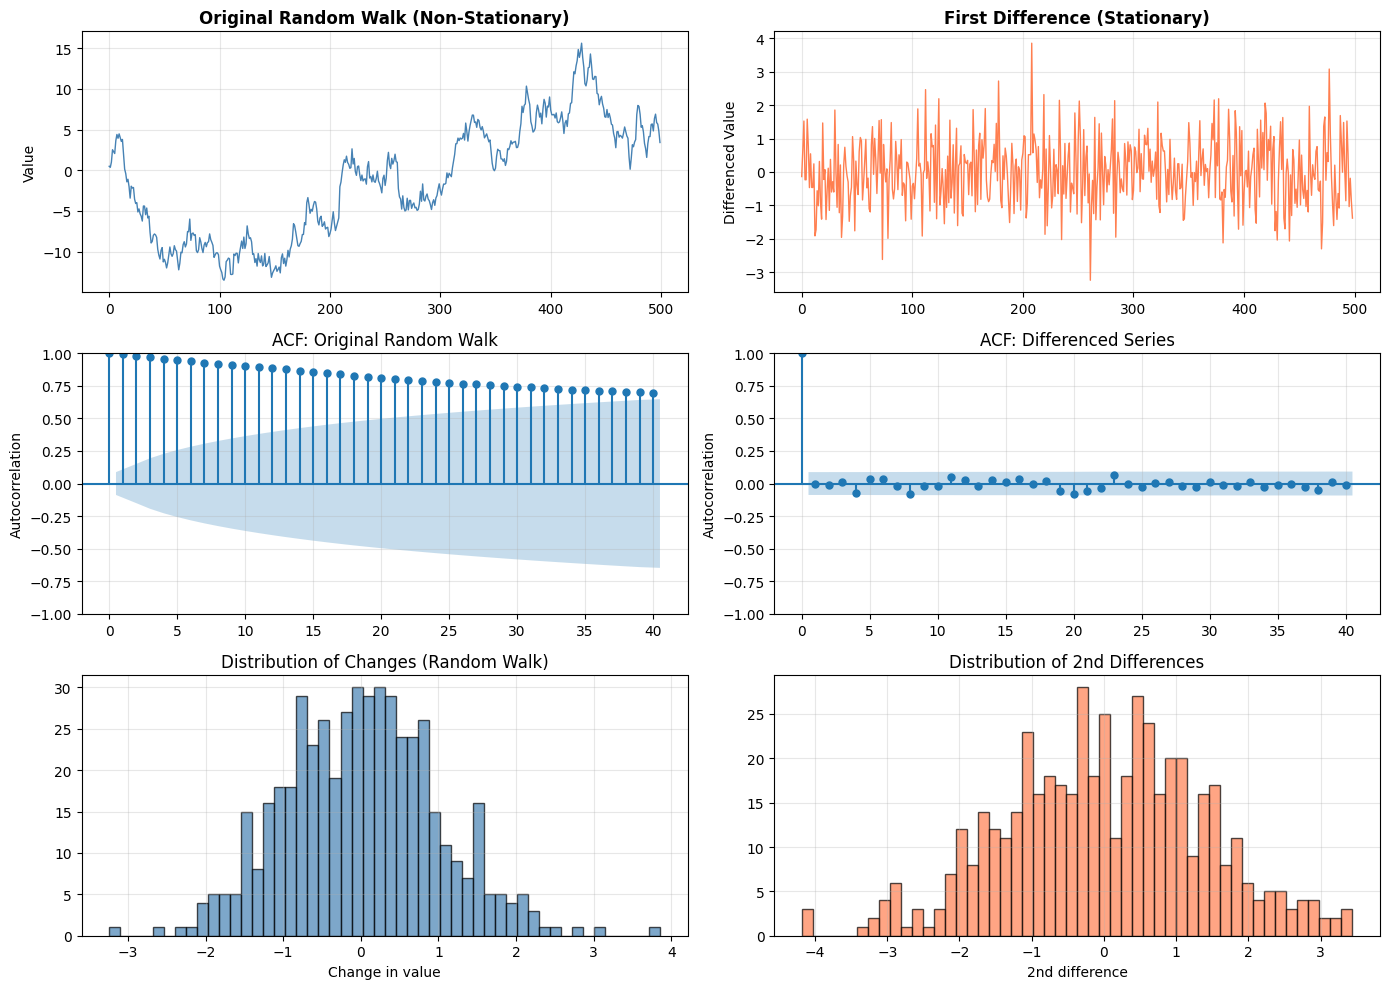

In [16]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# Generate a non-stationary random walk
np.random.seed(42)
n = 500
noise = np.random.randn(n)
random_walk = np.cumsum(noise)  # Cumulative sum = random walk (non-stationary)

# Create differenced series
differenced = np.diff(random_walk)

# Test stationarity
print("Stationarity Tests:")
print("-" * 50)
rw_adf = adfuller(random_walk)
print(f"Random Walk p-value: {rw_adf[1]:.6f} (non-stationary: p > 0.05)")

diff_adf = adfuller(differenced)
print(f"Differenced p-value: {diff_adf[1]:.6f} (stationary: p < 0.05)")

# Plot: original vs differenced
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Row 1: Time series
axes[0, 0].plot(random_walk, linewidth=1, color='steelblue')
axes[0, 0].set_title('Original Random Walk (Non-Stationary)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Value')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(differenced, linewidth=1, color='coral')
axes[0, 1].set_title('First Difference (Stationary)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Differenced Value')
axes[0, 1].grid(True, alpha=0.3)

# Row 2: ACF plots
plot_acf(random_walk, lags=40, ax=axes[1, 0], title='ACF: Original Random Walk')
axes[1, 0].set_ylabel('Autocorrelation')
axes[1, 0].grid(True, alpha=0.3)

plot_acf(differenced, lags=40, ax=axes[1, 1], title='ACF: Differenced Series')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].grid(True, alpha=0.3)

# Row 3: Histogram/distribution
axes[2, 0].hist(np.diff(random_walk), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[2, 0].set_title('Distribution of Changes (Random Walk)', fontsize=12)
axes[2, 0].set_xlabel('Change in value')
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].hist(np.diff(differenced), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[2, 1].set_title('Distribution of 2nd Differences', fontsize=12)
axes[2, 1].set_xlabel('2nd difference')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Summary: **

ARMA models have one core requirement: the data needs to be stationary. That means it should bounce around a fixed average, not drift up and down like it's on a random walk.

The random walk we generated perfectly shows what happens when we ignore this rule. Look at the original series (left side), it starts at 5, drops to -10, climbs back to 15. It's just wandering around with no anchor point. And that ACF plot? It's a dead giveaway. Those bars stay high across all 40 lags, barely dropping at all. That persistence screams "non-stationary", the series has memory that doesn't fade, which breaks ARMA's assumptions.

If we fit ARMA to non-stationary data, we'll get garbage forecasts that don't mean anything. The model can't tell the difference between a real pattern and a trend. So here's what you do: first, plot the ACF to see visually if the data is drifting (slow decay = red flag). Then run the ADF test to confirm statistically (p-value ≥ 0.05 = non-stationary). Once we've got that confirmation, difference the data until both the ACF and ADF test say it's stationary. Or just use ARIMA, which handles all that differencing automatically. Either way understand data visually first, then back it up with statistics, stationarity first, modeling second. this is what I learned from this exercise.



## Grading Rubric
- **Correctness (40%)**: Does the code run and produce the expected output?
- **Code Quality (30%)**: Is the code clean, commented, and efficient?
- **Analysis (30%)**: Are the interpretations and explanations clear and accurate?